In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="20" color="red">ch11.데이터 프래임과 시리즈(Pandas)</font>
# 9절. 데이터 그룹화 및 집계

In [7]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf.pivot_table

In [15]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [17]:
# 1) 그룹화방법 1
#     df.groupby(by=[그룹핑할열이름])[함수적용해서출력할열들].기초통계함수()
#     [함수적용해서출력할열들] 생략시 모든열이 적용
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum    #iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [19]:
# setosa, virginica 의 집계만
iris_grouped_sum.loc[['setosa','virginica']]


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [20]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [22]:
iris_grouped_sum.reset_index(inplace=True) #인덱스를 컬럼으로 편입시킴

In [23]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [24]:
# setosa, virginica 의 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa')|(iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin('setosa','virginica)

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [31]:
# 1) 그룹화방법 1-1: 그룹핑할때 index를 컬럼 데이터로 편입(reset_index()가 필요 없음) 
#     df.groupby(by=[그룹핑할열이름])as_index=False[함수적용해서출력할열들].기초통계함수()
#     [함수적용해서출력할열들] 생략시 모든열이 적용

iris.groupby(iris['Species'],as_index=False).sum
iris.groupby(iris.Species, as_index=False).sum
iris.groupby('Species',as_index=False).sum

<bound method GroupBy.sum of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x00000154FD8AA7A0>>

In [28]:
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [29]:
iris.groupby(iris['Species'], as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [32]:
#종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [33]:
#종별Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum()# 결과가 시리즈 1차원

Species
setosa        250.3
versicolor    296.8
virginica     329.4
Name: Sepal.Length, dtype: float64

In [35]:
#종별Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length',].sum()
iris.groupby('Species')[['Sepal.Length']].sum()# 결과가 시리즈 1차원

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [40]:
# 그룹화방법 1
#      df.groupby(by=[그룹필열이름들],as_index=T/F)[함수적용해서출력할열들].함수명()
# 그룹화방법 2
#      df.pivot_table(index='그룹핑할이름들',
#                    values='함수적용해서출력할열들',
#                     aggfunc=함수명(기본값:mean)
#                     )


g=iris.pivot_table(index='Species',
                # values=
                # aggfunc='mean'
                )

In [41]:
iris.groupby('Species').mean()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


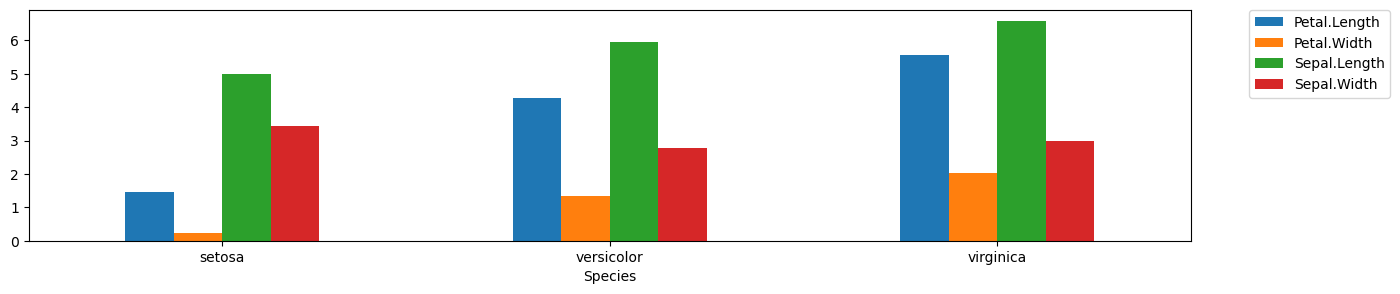

In [48]:
#범례를 밖으로 : 시각화 20page.판다스60page.
import matplotlib.pyplot as plt
g.plot(kind='bar',figsize=(15,3),rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [53]:
iris.pivot_table(index='Species',values='Sepal.Length',aggfunc='count')
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts()#정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [66]:
#임의로 각열마다 결측치를 할당(0번째 열은 결측치1/1번째 열은 결측치2/2번쨰 열은 결측치3/3번째 열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150),2)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)),col+1)
    iris.iloc[rows,col] = np.nan

In [68]:
# 열별 결측치를 제외한 데이터 갯수
# iris.isna().sum()
iris.groupby('Species').count()
iris.pivot_table(index='Species',aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,49,50,49
versicolor,49,49,49,49
virginica,49,48,50,50


### 다중열로 그룹화

In [69]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [79]:
# iris로 다중열 그룹화 하기위해 데이터 추가(num 컬럼 )
# iris 행수는 150개 =Species 3그룹,num 6그룹
iris['num']=np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [81]:
# 종별,num별 합계
r=iris.groupby(['Species','num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          35.0          5.9
           1           124.6         81.0          36.6          6.1
versicolor 2           143.7         66.6         107.8         33.6
           3           146.5         69.1         100.6         31.5
virginica  4           164.4         73.2         135.2         49.6
           5           165.0         75.5         136.6         48.2

In [83]:
r.loc[['setosa','virginica']]

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         87.0          35.0          5.9
          1           124.6         81.0          36.6          6.1
virginica 4           164.4         73.2         135.2         49.6
          5           165.0         75.5         136.6         48.2

In [84]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,35.0,5.9
virginica,5,165.0,75.5,136.6,48.2


In [85]:
# 종별,num별 합계
iris.pivot_table(index=['Species','num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.458333     0.245833        5.0280        3.480
           1        1.464000     0.244000        4.9840        3.375
versicolor 2        4.312000     1.344000        5.9875        2.775
           3        4.191667     1.312500        5.8600        2.764
virginica  4        5.633333     2.066667        6.5760        2.928
           5        5.464000     2.008333        6.6000        3.020

In [87]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   49.000000  50.000000
             mean    5.006000    5.922449   6.588000
             std     0.352490    0.512455   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  50.000000
             mean    3.428571    2.769388   2.974000
             std     0.382971    0.317020   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
Petal.Length count  49.000000   49.000000  49.000000
             mean    1.461224    4.253061   5.546939
             std     0.175376    0.472186   0.556440
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.300000   5.500000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  49.000000   49.000000  48.000000
             mean    0.244898    1.328571   2.037500
             std     0.106186    0.198956   0.269456
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000